# Sensitivity Analyses for Component Decomposition

This notebook runs sensitivity analyses that support the core results in
`component_decomposition_refactor.ipynb`:

1. **Uncertainty taper sensitivity** — How results change with f_max = {1, 2, 3}
2. **Model selection** — Linear vs quadratic for each component
3. **Greenland temperature choice** — Local T vs GMST
4. **Endpoint rate discrepancy** — Observed vs model-implied rates

All fits are independent of the main notebook state.

---

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from slr_data_readers import (
    read_berkeley_earth, read_berkeley_earth_gridded,
    read_imbie_west_antarctica,
)
from slr_forecast.readers.ice_sheets import (
    read_mouginot2019_greenland, read_mankoff2021_greenland,
)
from bayesian_dols import (
    build_level_design_vectors, fit_bayesian_level,
    calibrate_exponential_prior,
)
from slr_analysis import compute_kinematics
from component_analysis import (
    annualize_imbie, apply_sigma_taper,
    model_ensemble_draws, compute_component_rates,
)
from component_plotting import (
    plot_taper_sensitivity, plot_greenland_local_vs_gmst,
    PANEL_COLORS, TAPER_BLUES, TAPER_REDS, M_TO_MM,
)

H5_PATH   = '../data/processed/slr_processed_data.h5'
RAW_DIR   = '../data/raw'
FIG_DIR   = '../figures'
BASELINE_YEAR = 2005.0
M_TO_MM = 1000.0

# ── Load data (same as main notebook) ──
df_fred = pd.read_hdf(H5_PATH, 'derived/df_frederikse_thermo')
fred_year = df_fred['year'].values
fred_steric = df_fred['steric'].values
fred_steric_sigma = df_fred['steric_sigma'].values
fred_glaciers = df_fred['glaciers'].values
fred_glaciers_sigma = df_fred['glaciers_sigma'].values
fred_greenland = df_fred['greenland'].values
fred_greenland_sigma = df_fred['greenland_sigma'].values
fred_antarctica = df_fred['antarctica'].values
fred_antarctica_sigma = df_fred['antarctica_sigma'].values
fred_gmsl = df_fred['gmsl'].values
fred_gmsl_sigma = df_fred['gmsl_sigma'].values

baseline_idx = np.argmin(np.abs(fred_year - BASELINE_YEAR))
steric_rebase = fred_steric - fred_steric[baseline_idx]
glacier_rebase = fred_glaciers - fred_glaciers[baseline_idx]
gmsl_rebase = fred_gmsl - fred_gmsl[baseline_idx]

# Temperature
df_temp = pd.read_hdf(H5_PATH, 'harmonized/df_berkeley_h')
temp_time_monthly = (df_temp.index.year + (df_temp.index.month - 0.5) / 12.0).values
temp_monthly = df_temp['temperature'].values
T_annual = pd.Series(temp_monthly, index=temp_time_monthly).groupby(
    np.floor(temp_time_monthly)).mean()

# Design vectors (full Frederikse)
design = build_level_design_vectors(
    temperature_monthly=temp_monthly, time_monthly=temp_time_monthly,
    obs_times=fred_year)
I2_obs = design['I2_obs']
I1_obs = design['I1_obs']
I0_obs = design['I0_obs']

# Greenland
df_mouginot = read_mouginot2019_greenland(
    f'{RAW_DIR}/ice_sheets/greenland/mouginot2019_data.xlsx')
mou_year = df_mouginot['decimal_year'].values.astype(float)
mou_greenland = df_mouginot['cumulative_mb'].values
mou_greenland_sigma = df_mouginot['cumulative_mb_sigma'].values
_bl = np.argmin(np.abs(mou_year - BASELINE_YEAR))
mou_greenland -= mou_greenland[_bl]

df_mankoff = read_mankoff2021_greenland(
    f'{RAW_DIR}/ice_sheets/greenland/mankoff/MB_SMB_D_BMB_ann.csv', obs_only=True)
man_year = df_mankoff['decimal_year'].values.astype(float)
man_greenland = np.cumsum(df_mankoff['mb_rate'].values)
man_greenland_sigma = np.sqrt(np.cumsum(df_mankoff['mb_rate_sigma'].values**2))
_bl = np.argmin(np.abs(man_year - BASELINE_YEAR))
man_greenland -= man_greenland[_bl]

grn_year_combined = np.concatenate([mou_year, man_year])
grn_combined = np.concatenate([mou_greenland, man_greenland])
grn_sigma_combined = np.concatenate([mou_greenland_sigma, man_greenland_sigma])
sort_idx = np.argsort(grn_year_combined)
grn_year_combined = grn_year_combined[sort_idx]
grn_combined = grn_combined[sort_idx]
grn_sigma_combined = grn_sigma_combined[sort_idx]

# IMBIE sub-Antarctic
import os
IMBIE_MM_DIR = f'{RAW_DIR}/ice_sheets/antarctica'
df_eais_monthly = read_imbie_west_antarctica(os.path.join(IMBIE_MM_DIR, 'imbie_east_antarctica_2021_mm.csv'))
df_pen_monthly = read_imbie_west_antarctica(os.path.join(IMBIE_MM_DIR, 'imbie_antarctic_peninsula_2021_mm.csv'))
for df in [df_eais_monthly, df_pen_monthly]:
    df['cumulative_mass_balance_sigma'] = df['cumulative_mass_balance_sigma'].abs()
    df['mass_balance_rate_sigma'] = df['mass_balance_rate_sigma'].abs()

eais_year, eais_rebase, eais_sigma = annualize_imbie(df_eais_monthly)
pen_year, pen_rebase, pen_sigma = annualize_imbie(df_pen_monthly)

design_imbie = build_level_design_vectors(
    temperature_monthly=temp_monthly, time_monthly=temp_time_monthly,
    obs_times=eais_year)
I2_imbie = design_imbie['I2_obs']
I1_imbie = design_imbie['I1_obs']
I0_imbie = design_imbie['I0_obs']

print('Data loaded OK')

Data loaded OK


## 1. Uncertainty Taper Sensitivity

Run fits for f_max = {1, 2, 3} across all components to test how σ inflation
affects the quadratic coefficient *a* and model selection.

In [10]:
# ── Prior configurations ──
from bayesian_dols import check_convergence

PRIOR_SCALE_A_THERMO = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.002)
PRIOR_SCALE_A_GLACIER = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.003)
PRIOR_SCALE_A_GR = calibrate_exponential_prior(prob_exceed=0.20, threshold=0.003)
PRIOR_SCALE_A_EAIS = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.001)
PRIOR_SCALE_A_TOTAL = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.005)

prior_configs = {
    'Thermosteric': dict(
        prior_scale_a=PRIOR_SCALE_A_THERMO, prior_scale_b=0.005,
        prior_c_mean=0.0005, prior_c_sigma=0.002,
        prior_sigma_extra_scale=0.002, prior_H0_sigma=0.010),
    'Glaciers': dict(
        prior_scale_a=PRIOR_SCALE_A_GLACIER, prior_scale_b=0.005,
        prior_c_mean=0.0003, prior_c_sigma=0.002,
        prior_sigma_extra_scale=0.002, prior_H0_sigma=0.010),
    'Greenland': dict(
        prior_scale_a=PRIOR_SCALE_A_GR, prior_scale_b=0.004,
        prior_c_mean=0.0002, prior_c_sigma=0.00015,
        prior_sigma_extra_scale=0.002, prior_H0_sigma=0.005),
    'Total GMSL': dict(
        prior_scale_a=PRIOR_SCALE_A_TOTAL, prior_scale_b=0.010,
        prior_c_mean=0.002, prior_c_sigma=0.005,
        prior_sigma_extra_scale=0.005, prior_H0_sigma=0.050),
}

obs_windows = {
    'Thermosteric': (1957, 2018), 'Glaciers': (1961, 2018),
    'Greenland': (1972, 2018), 'Total GMSL': (1957, 2018),
}
TAPER_REFS = {
    'Thermosteric': 2005, 'Glaciers': 2000,
    'Greenland': 2002, 'Total GMSL': 2000,
}

taper_component_data = {
    'Thermosteric': (fred_steric, fred_steric_sigma, fred_year),
    'Glaciers': (fred_glaciers, fred_glaciers_sigma, fred_year),
    'Greenland': (grn_combined, grn_sigma_combined, grn_year_combined),
    'Total GMSL': (fred_gmsl, fred_gmsl_sigma, fred_year),
}

F_MAX_VALUES = [1, 2, 3]
taper_results = {}
taper_restricted_data = {}

# ── Diagnostics log ──
DIAG_PATH = 'diagnostics/component_decomp_sensitivities_outputs01.md'
diag_lines = ['# Taper Sensitivity — Fit Diagnostics\n']

def log_diag(msg):
    """Print and append to diagnostics log."""
    print(msg)
    diag_lines.append(msg + '\n')

def report_fit(label, result):
    """Log convergence diagnostics for a single fit."""
    conv = check_convergence(result.trace, quiet=True)
    status = 'CONVERGED' if conv['converged'] else '** NOT CONVERGED **'
    log_diag(f'  {label}: R²={result.r2:.4f}  {status}')

    # R-hat
    rhat_strs = [f'{k}={v:.4f}' for k, v in conv['rhat'].items()]
    log_diag(f'    R-hat: {", ".join(rhat_strs)}')

    # ESS (bulk)
    ess_strs = [f'{k}={v:.0f}' for k, v in conv['ess_bulk'].items()]
    log_diag(f'    ESS_bulk: {", ".join(ess_strs)}')

    # ESS (tail)
    ess_tail_strs = [f'{k}={v:.0f}' for k, v in conv['ess_tail'].items()]
    log_diag(f'    ESS_tail: {", ".join(ess_tail_strs)}')

    # Acceptance fraction
    if result.sampler_diagnostics and 'acceptance_fraction' in result.sampler_diagnostics:
        af = result.sampler_diagnostics['acceptance_fraction']
        log_diag(f'    Acceptance fraction: {af:.3f}')

    # Warnings
    for w in conv.get('warnings', []):
        log_diag(f'    WARNING: {w}')

    # Posterior summary (median [5, 95])
    samples = result.posterior_samples
    for j, pname in enumerate(['a', 'b', 'c']):
        s = samples[:, j] * M_TO_MM
        p5, med, p95 = np.percentile(s, [5, 50, 95])
        log_diag(f'    {pname}: {med:.4f} [{p5:.4f}, {p95:.4f}] mm units')

    return conv['converged']

# ═══════════════════════════════════════════════════════════════════
# Frederikse components + Total GMSL (taper loop)
# ═══════════════════════════════════════════════════════════════════
n_not_converged = 0

for f_max in F_MAX_VALUES:
    log_diag(f'\n## f_max = {f_max}\n')
    taper_results[f_max] = {}

    for name, (H_full, sig_full, yrs_full) in taper_component_data.items():
        ow = obs_windows[name]
        mask = (yrs_full >= ow[0]) & (yrs_full <= ow[1])
        yrs_r = yrs_full[mask]
        H_r = H_full[mask].copy()
        sig_r = sig_full[mask].copy()
        bl_r = np.argmin(np.abs(yrs_r - BASELINE_YEAR))
        H_r -= H_r[bl_r]
        sig_tapered = apply_sigma_taper(sig_r, yrs_r, TAPER_REFS[name], f_max)

        design_r = build_level_design_vectors(
            temperature_monthly=temp_monthly, time_monthly=temp_time_monthly,
            obs_times=yrs_r)

        if f_max == 1:
            taper_restricted_data[name] = {
                'years': yrs_r, 'window': ow, 'design': design_r}

        log_diag(f'### {name} (f_max={f_max}, {ow[0]}–{ow[1]}, n={len(yrs_r)})')

        log_diag(f'  Fitting quadratic...')
        res_q = fit_bayesian_level(
            H_obs=H_r, sigma_obs=sig_tapered,
            I2_obs=design_r['I2_obs'], I1_obs=design_r['I1_obs'], I0_obs=design_r['I0_obs'],
            n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
            seed=200 + f_max*100 + hash(name) % 50, **prior_configs[name])
        ok_q = report_fit(f'{name} quadratic', res_q)
        if not ok_q:
            n_not_converged += 1

        log_diag(f'  Fitting linear...')
        res_l = fit_bayesian_level(
            H_obs=H_r, sigma_obs=sig_tapered,
            I2_obs=np.zeros_like(design_r['I2_obs']),
            I1_obs=design_r['I1_obs'], I0_obs=design_r['I0_obs'],
            n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
            seed=300 + f_max*100 + hash(name) % 50, **prior_configs[name])
        ok_l = report_fit(f'{name} linear', res_l)
        if not ok_l:
            n_not_converged += 1

        taper_results[f_max][name] = {'quad': res_q, 'linear': res_l}
        log_diag('')

    # ── EAIS and Peninsula (satellite-era only, no taper) ──
    ice_prior = dict(
        prior_scale_a=PRIOR_SCALE_A_EAIS, prior_scale_b=0.002,
        prior_c_mean=0.0, prior_c_sigma=0.001,
        prior_sigma_extra_scale=0.001, prior_H0_sigma=0.002)

    for ice_name, ice_data, ice_sigma, seed_base in [
        ('EAIS', eais_rebase, eais_sigma, 55),
        ('Peninsula', pen_rebase, pen_sigma, 56),
    ]:
        n_ice = len(ice_data)
        log_diag(f'### {ice_name} (f_max={f_max}, 1992–2020, n={n_ice})')

        log_diag(f'  Fitting quadratic...')
        res_q = fit_bayesian_level(
            H_obs=ice_data, sigma_obs=ice_sigma,
            I2_obs=I2_imbie, I1_obs=I1_imbie, I0_obs=I0_imbie,
            n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
            seed=seed_base, **ice_prior)
        ok_q = report_fit(f'{ice_name} quadratic', res_q)
        if not ok_q:
            n_not_converged += 1

        log_diag(f'  Fitting linear...')
        res_l = fit_bayesian_level(
            H_obs=ice_data, sigma_obs=ice_sigma,
            I2_obs=np.zeros_like(I2_imbie), I1_obs=I1_imbie, I0_obs=I0_imbie,
            n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
            seed=seed_base + 100, **ice_prior)
        ok_l = report_fit(f'{ice_name} linear', res_l)
        if not ok_l:
            n_not_converged += 1

        taper_results[f_max][ice_name] = {'quad': res_q, 'linear': res_l}
        if f_max == 1:
            taper_restricted_data[ice_name] = {
                'years': eais_year if ice_name == 'EAIS' else pen_year,
                'window': (1992, 2020)}
        log_diag('')

# ── Summary and write ──
log_diag(f'\n## Summary\n')
total_fits = len(F_MAX_VALUES) * (len(taper_component_data) * 2 + 2 * 2)
log_diag(f'Total fits: {total_fits}')
log_diag(f'Not converged: {n_not_converged}')

with open(DIAG_PATH, 'w') as f:
    f.writelines(diag_lines)
print(f'\nDiagnostics written to {DIAG_PATH}')


## f_max = 1

### Thermosteric (f_max=1, 1957–2018, n=62)
  Fitting quadratic...
Bayesian level-space fit: n=62 observations, ndim=5
  Priors: a~Exp(mean=0.87 mm/yr/°C²), b~HN(5.0 mm/yr/°C), c~N(0.5, 2.0 mm/yr), σ_extra~HC(2.0 mm)
  OLS init: a=0.137, b=1.340, c=1.029 mm/yr, σ_extra=1.87 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:08<00:00, 747.40it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.032  ESS_bulk=174  ESS_tail=497
    alpha0: R-hat=1.021  ESS_bulk=225  ESS_tail=441
    trend: R-hat=1.010  ESS_bulk=295  ESS_tail=883
    log_sigma_extra: R-hat=1.008  ESS_bulk=200  ESS_tail=713
    H0: R-hat=1.022  ESS_bulk=228  ESS_tail=585
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.157, b=1.321, c=1.030 mm/yr
  σ_extra: median=1.20 mm [0.83, 1.67]
  R² = 0.9796,  acceptance = 0.52
  Thermosteric quadratic: R²=0.9796  CONVERGED
    R-hat: dalpha_dT=1.0324, alpha0=1.0205, trend=1.0103, log_sigma_extra=1.0084, H0=1.0215
    ESS_bulk: dalpha_dT=174, alpha0=225, trend=295, log_sigma_extra=200, H0=228
    ESS_tail: dalpha_dT=497, alpha0=441, trend=883, log_sigma_extra=713, H0=585
    Acceptance fraction: 0.520
    a: 0.1222 [0.0107, 0.4289] mm units
    b: 1.3104 [1.1522, 1.5219] mm units
    c: 1.0299 [0.9931, 1.0685] mm units
  Fitting linear...
Bayesian level-space fit: n=62 observations, ndim=5
  Priors: a~Ex

100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 758.84it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.018  ESS_bulk=194  ESS_tail=249
    alpha0: R-hat=1.008  ESS_bulk=240  ESS_tail=687
    trend: R-hat=1.005  ESS_bulk=275  ESS_tail=740
    log_sigma_extra: R-hat=1.008  ESS_bulk=204  ESS_tail=623
    H0: R-hat=1.013  ESS_bulk=223  ESS_tail=692
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.858, b=1.228, c=1.032 mm/yr
  σ_extra: median=1.15 mm [0.80, 1.63]
  R² = 0.9795,  acceptance = 0.51
  Thermosteric linear: R²=0.9795  CONVERGED
    R-hat: dalpha_dT=1.0183, alpha0=1.0078, trend=1.0049, log_sigma_extra=1.0084, H0=1.0127
    ESS_bulk: dalpha_dT=194, alpha0=240, trend=275, log_sigma_extra=204, H0=223
    ESS_tail: dalpha_dT=249, alpha0=687, trend=740, log_sigma_extra=623, H0=692
    Acceptance fraction: 0.511
    a: 0.5848 [0.0452, 2.6018] mm units
    b: 1.2276 [1.1008, 1.3601] mm units
    c: 1.0313 [0.9964, 1.0676] mm units

### Glaciers (f_max=1, 1961–2018, n=58)
  Fitting quadratic...
Bayesian level-space fit:

...

  Convergence diagnostics:
    dalpha_dT: R-hat=1.021  ESS_bulk=184  ESS_tail=345
    alpha0: R-hat=1.033  ESS_bulk=212  ESS_tail=583
    trend: R-hat=1.011  ESS_bulk=231  ESS_tail=591
    log_sigma_extra: R-hat=1.010  ESS_bulk=294  ESS_tail=535
    H0: R-hat=1.031  ESS_bulk=212  ESS_tail=597
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.444, b=0.000, c=-0.000 mm/yr
  σ_extra: median=0.00 mm [0.00, 0.00]
  R² = 0.6420,  acceptance = 0.48
  EAIS linear: R²=0.6420  CONVERGED
    R-hat: dalpha_dT=1.0214, alpha0=1.0327, trend=1.0111, log_sigma_extra=1.0101, H0=1.0309
    ESS_bulk: dalpha_dT=184, alpha0=212, trend=231, log_sigma_extra=294, H0=212
    ESS_tail: dalpha_dT=345, alpha0=583, trend=591, log_sigma_extra=535, H0=597
    Acceptance fraction: 0.476
    a: 0.3109 [0.0234, 1.3110] mm units
    b: 0.0001 [0.0000, 0.0003] mm units
    c: -0.0000 [-0.0001, -0.0000] mm units

### Peninsula (f_max=3, 1992–2020, n=29)
  Fitting quadratic...
Bayesian level-space fit: n=

100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 797.24it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.017  ESS_bulk=194  ESS_tail=455
    alpha0: R-hat=1.013  ESS_bulk=259  ESS_tail=622
    trend: R-hat=1.023  ESS_bulk=172  ESS_tail=478
    log_sigma_extra: R-hat=1.011  ESS_bulk=231  ESS_tail=361
    H0: R-hat=1.014  ESS_bulk=184  ESS_tail=464
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.000, b=0.000, c=0.000 mm/yr
  σ_extra: median=0.00 mm [0.00, 0.00]
  R² = 0.8930,  acceptance = 0.51
  Peninsula quadratic: R²=0.8930  CONVERGED
    R-hat: dalpha_dT=1.0171, alpha0=1.0131, trend=1.0230, log_sigma_extra=1.0109, H0=1.0139
    ESS_bulk: dalpha_dT=194, alpha0=259, trend=172, log_sigma_extra=231, H0=184
    ESS_tail: dalpha_dT=455, alpha0=622, trend=478, log_sigma_extra=361, H0=464
    Acceptance fraction: 0.505
    a: 0.0002 [0.0000, 0.0006] mm units
    b: 0.0001 [0.0000, 0.0002] mm units
    c: 0.0000 [0.0000, 0.0000] mm units
  Fitting linear...
Bayesian level-space fit: n=29 observations, ndim=5
  Priors: a~Exp(m

100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 793.40it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.013  ESS_bulk=230  ESS_tail=354
    alpha0: R-hat=1.023  ESS_bulk=208  ESS_tail=695
    trend: R-hat=1.042  ESS_bulk=162  ESS_tail=691
    log_sigma_extra: R-hat=1.010  ESS_bulk=227  ESS_tail=442
    H0: R-hat=1.027  ESS_bulk=206  ESS_tail=730
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.418, b=0.000, c=0.000 mm/yr
  σ_extra: median=0.00 mm [0.00, 0.00]
  R² = 0.9398,  acceptance = 0.50
  Peninsula linear: R²=0.9398  CONVERGED
    R-hat: dalpha_dT=1.0127, alpha0=1.0232, trend=1.0423, log_sigma_extra=1.0104, H0=1.0274
    ESS_bulk: dalpha_dT=230, alpha0=208, trend=162, log_sigma_extra=227, H0=206
    ESS_tail: dalpha_dT=354, alpha0=695, trend=691, log_sigma_extra=442, H0=730
    Acceptance fraction: 0.500
    a: 0.2960 [0.0221, 1.2239] mm units
    b: 0.0001 [0.0000, 0.0002] mm units
    c: 0.0000 [0.0000, 0.0000] mm units


## Summary

Total fits: 36
Not converged: 0

Diagnostics written to diagnostics/component_

In [11]:
# ── Taper sensitivity summary table ──
all_components = ['Total GMSL', 'Thermosteric', 'Glaciers', 'Greenland', 'EAIS', 'Peninsula']

print('=' * 115)
print('TAPER SENSITIVITY (observation-constrained + σ inflation)')
print('=' * 115)
print(f'{"Component":<16} {"f_max":>5}  {"a (mm/yr/°C²)":>16}  {"P(a>0)":>7}  {"R²_quad":>7}  {"R²_lin":>7}  {"ΔBIC":>7}')
print('-' * 115)

for name in all_components:
    n = len(taper_restricted_data[name]['years'])
    for i, f_max in enumerate(F_MAX_VALUES):
        tr = taper_results[f_max][name]
        a_s = tr['quad'].posterior_samples[:, 0] * M_TO_MM
        a_med = np.median(a_s)
        a_p5, a_p95 = np.percentile(a_s, [5, 95])
        p_a_pos = np.mean(tr['quad'].posterior_samples[:, 0] > 0)
        rss_q = np.sum(tr['quad'].residuals**2)
        rss_l = np.sum(tr['linear'].residuals**2)
        bic_q = n * np.log(rss_q / n) + 5 * np.log(n)
        bic_l = n * np.log(rss_l / n) + 4 * np.log(n)
        delta_bic = bic_l - bic_q

        label = name if i == 0 else ''
        print(f'{label:<16} {f_max:>5}  {a_med:>16.4f}  {p_a_pos:>7.2f}  '
              f'{tr["quad"].r2:>7.4f}  {tr["linear"].r2:>7.4f}  {delta_bic:>+7.1f}')
    print('-' * 115)

TAPER SENSITIVITY (observation-constrained + σ inflation)
Component        f_max     a (mm/yr/°C²)   P(a>0)  R²_quad   R²_lin     ΔBIC
-------------------------------------------------------------------------------------------------------------------
Total GMSL           1            1.6277     1.00   0.9761   0.9750     -1.2
                     2            1.5619     1.00   0.9761   0.9748     -0.8
                     3            1.5874     1.00   0.9761   0.9745     +0.1
-------------------------------------------------------------------------------------------------------------------
Thermosteric         1            0.1222     1.00   0.9796   0.9795     -3.7
                     2            0.1062     1.00   0.9794   0.9792     -3.3
                     3            0.1009     1.00   0.9794   0.9791     -3.3
-------------------------------------------------------------------------------------------------------------------
Glaciers             1            0.0365     1.00   0.9

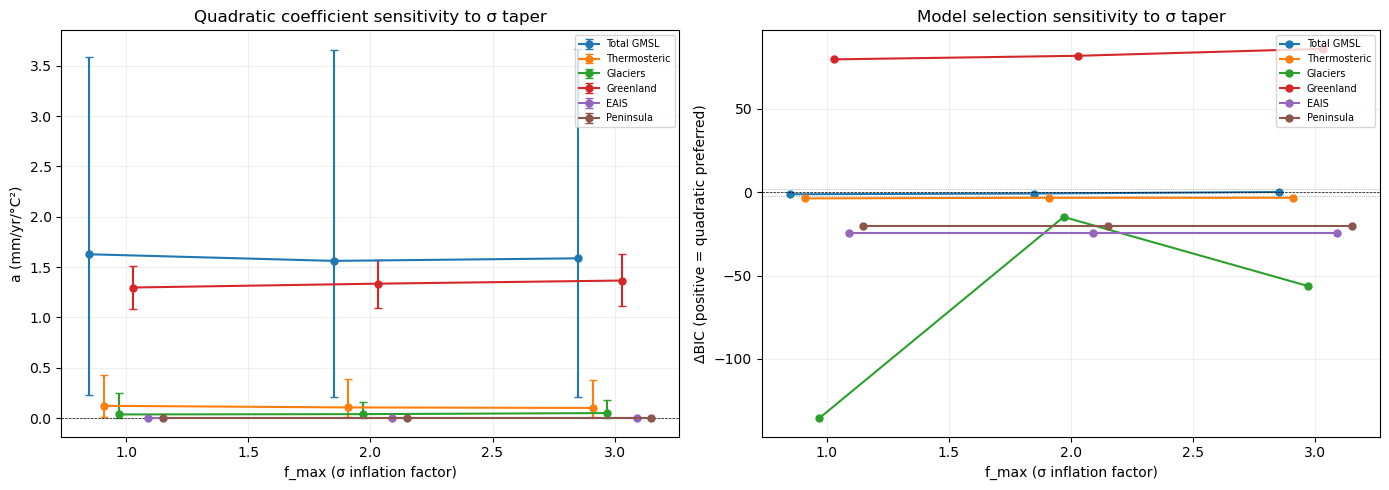

In [12]:
plot_taper_sensitivity(
    taper_results, all_components, F_MAX_VALUES, taper_restricted_data,
    eais_year=eais_year, pen_year=pen_year,
    save_path=f'{FIG_DIR}/component_taper_sensitivity.png',
)

## 2. Model Selection — Linear vs Quadratic

Compare BIC for linear vs quadratic models across components.
Linear models are preferred for all individual components.

In [13]:
# ── Model comparison: observation-constrained ──
print('MODEL SELECTION — OBSERVATION-CONSTRAINED PERIODS')
print('=' * 95)
print(f'{"Component":<16} {"Period":>11} {"n":>4} {"R²_lin":>7} {"R²_quad":>8} '
      f'{"ΔBIC":>8} {"a_med":>8} {"P(a>0)":>7} {"Verdict":>10}')
print('-' * 95)

for name in all_components:
    n = len(taper_restricted_data[name]['years'])
    w = taper_restricted_data[name]['window']
    tr = taper_results[1][name]  # f_max=1
    a_s = tr['quad'].posterior_samples[:, 0] * M_TO_MM
    a_med = np.median(a_s)
    p_a = np.mean(tr['quad'].posterior_samples[:, 0] > 0)

    rss_q = np.sum(tr['quad'].residuals**2)
    rss_l = np.sum(tr['linear'].residuals**2)
    bic_q = n * np.log(rss_q / n) + 5 * np.log(n)
    bic_l = n * np.log(rss_l / n) + 4 * np.log(n)
    dbic = bic_l - bic_q
    verdict = 'Quadratic' if dbic > 2 else ('Linear' if dbic < -2 else 'Inconclusive')

    print(f'{name:<16} {w[0]}–{w[1]:>4} {n:>4} {tr["linear"].r2:>7.4f} {tr["quad"].r2:>8.4f} '
          f'{dbic:>+8.1f} {a_med:>8.4f} {p_a:>7.2f} {verdict:>10}')
print('=' * 95)

MODEL SELECTION — OBSERVATION-CONSTRAINED PERIODS
Component             Period    n  R²_lin  R²_quad     ΔBIC    a_med  P(a>0)    Verdict
-----------------------------------------------------------------------------------------------
Total GMSL       1957–2018   62  0.9750   0.9761     -1.2   1.6277    1.00 Inconclusive
Thermosteric     1957–2018   62  0.9795   0.9796     -3.7   0.1222    1.00     Linear
Glaciers         1961–2018   58  0.9907   0.9099   -135.5   0.0365    1.00     Linear
Greenland        1972–2018   78  0.9443   0.9810    +79.7   1.2975    1.00  Quadratic
EAIS             1992–2020   29  0.6420   0.2590    -24.5   0.0009    1.00     Linear
Peninsula        1992–2020   29  0.9398   0.8930    -20.0   0.0002    1.00     Linear


Thermosteric   : 119/119 valid rate estimates
Glaciers       : 119/119 valid rate estimates
Greenland      : 119/119 valid rate estimates
Total GMSL     : 119/119 valid rate estimates
EAIS           : 29/29 valid rate estimates
Peninsula      : 29/29 valid rate estimates


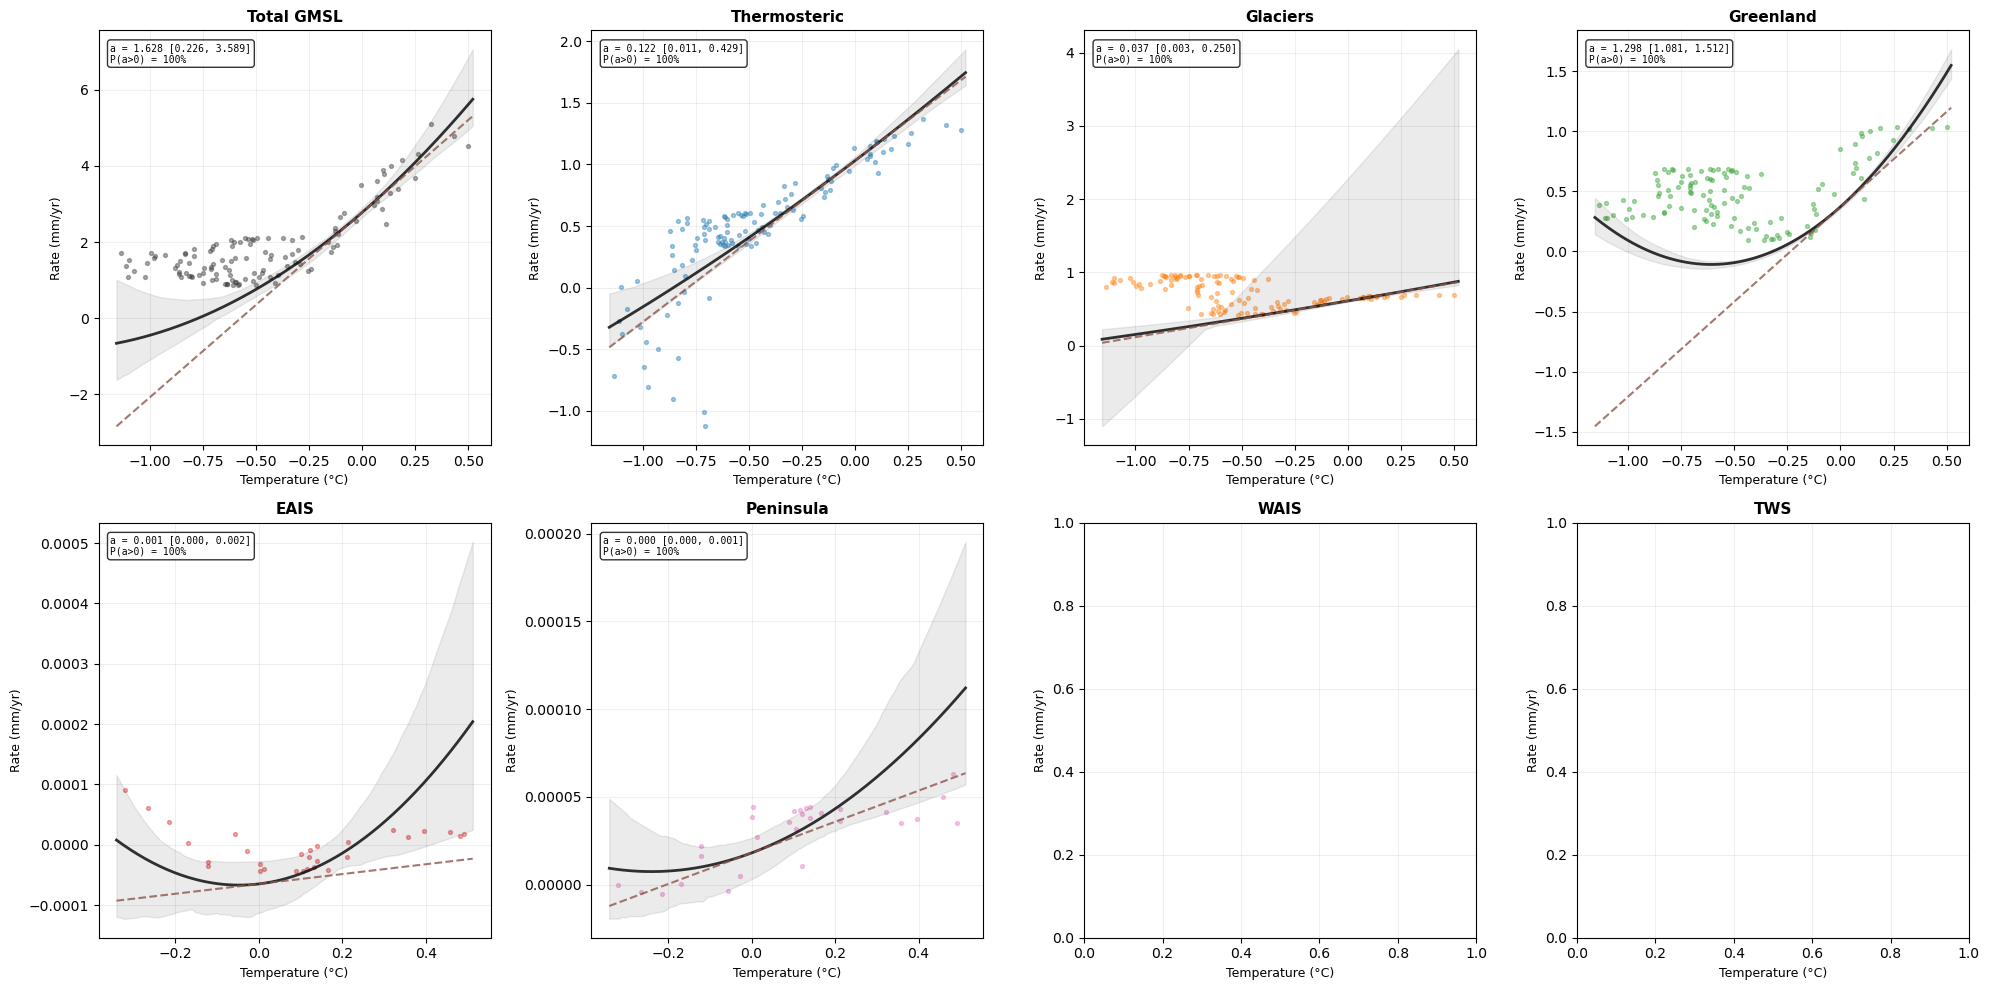

In [15]:
# ── Rate vs T with linear + quadratic overlays ──
# Compute kernel-smoothed rates for scatter using compute_kinematics
# (requires: time, value, sigma, span_years)

SPAN_FRED  = 30.0   # years — long records (Frederikse)
SPAN_IMBIE = 15.0   # years — short records (IMBIE, 29 yr)

# Annual temperature on each time grid
T_annual_arr = np.array([
    np.mean(temp_monthly[
        (temp_time_monthly >= yr - 0.5) & (temp_time_monthly < yr + 0.5)
    ]) for yr in fred_year
])
T_annual_imbie = np.array([
    np.mean(temp_monthly[
        (temp_time_monthly >= yr - 0.5) & (temp_time_monthly < yr + 0.5)
    ]) for yr in eais_year
])

T_annual_vals = T_annual_arr   # alias for plotting functions
T_annual_idx = fred_year       # alias for np.interp calls

# All components for rate computation
all_rate_components = {
    'Thermosteric': (fred_year, fred_steric,    fred_steric_sigma,    SPAN_FRED),
    'Glaciers':     (fred_year, fred_glaciers,  fred_glaciers_sigma,  SPAN_FRED),
    'Greenland':    (fred_year, fred_greenland, fred_greenland_sigma, SPAN_FRED),
    'Total GMSL':   (fred_year, fred_gmsl,      fred_gmsl_sigma,     SPAN_FRED),
    'EAIS':         (eais_year, eais_rebase,     eais_sigma,          SPAN_IMBIE),
    'Peninsula':    (pen_year,  pen_rebase,      pen_sigma,           SPAN_IMBIE),
}

rates = {}
rates_se = {}
T_for_rate = {}

for name, (yr, h, sig, span) in all_rate_components.items():
    sig_safe = np.maximum(np.abs(sig), 1e-6)
    kin = compute_kinematics(
        time=yr.astype(float),
        value=h,
        sigma=sig_safe,
        span_years=span,
        min_effective_obs=6,
    )
    rates[name] = kin.rate * M_TO_MM
    rates_se[name] = kin.rate_se * M_TO_MM

    if len(yr) == len(fred_year) and np.allclose(yr, fred_year):
        T_for_rate[name] = T_annual_arr
    else:
        T_for_rate[name] = T_annual_imbie

    n_valid = np.sum(np.isfinite(kin.rate))
    print(f'{name:15s}: {n_valid}/{len(yr)} valid rate estimates')

# Model-implied rates from taper fits (quadratic posteriors)
model_rates = {}
for name in ['Thermosteric', 'Glaciers', 'Greenland', 'Total GMSL', 'EAIS', 'Peninsula']:
    if name in taper_results[1]:
        tr = taper_results[1][name]
        model_rates[name] = {
            'a': tr['quad'].posterior_samples[:, 0],
            'b': tr['quad'].posterior_samples[:, 1],
            'c': tr['quad'].posterior_samples[:, 2],
        }

panel_order = ['Total GMSL', 'Thermosteric', 'Glaciers', 'Greenland',
               'EAIS', 'Peninsula', 'WAIS', 'TWS']

from component_plotting import plot_rate_vs_temperature

plot_rate_vs_temperature(
    panel_order, rates, T_for_rate, model_rates, T_annual_vals,
    save_path=f'{FIG_DIR}/component_rate_vs_T_model_selection.png',
)

## 3. Greenland Temperature Choice

Compare Greenland fits using local Greenland temperature vs GMST.
Greenland T provides much wider temperature range due to Arctic amplification (~2.6×).

In [16]:
# ── Load Greenland regional temperature (gridded NetCDF) ──
GRIDDED_PATH = f'{RAW_DIR}/gmst/berkEarth_Global_TAVG_Gridded_1deg.nc'
df_gr_temp = read_berkeley_earth_gridded(GRIDDED_PATH)  # defaults to Greenland

gr_temp_raw = df_gr_temp['temperature'].values
gr_time_raw = df_gr_temp['decimal_year'].values

# Rebaseline to 1995-2005
bl_mask = (gr_time_raw >= 1995.0) & (gr_time_raw < 2006.0)
gr_temp_monthly_rebased = gr_temp_raw - np.nanmean(gr_temp_raw[bl_mask])

# Drop NaN months
valid_gr = np.isfinite(gr_temp_monthly_rebased)
gr_temp_monthly_rebased = gr_temp_monthly_rebased[valid_gr]
gr_time_raw = gr_time_raw[valid_gr]

# Greenland observation window (limited by Berkeley Earth)
GR_OBS_WINDOW_LOCAL = (1972, 2015)
GR_TAPER_REF = 2002

mask_gr_obs = (grn_year_combined >= GR_OBS_WINDOW_LOCAL[0]) & (grn_year_combined <= GR_OBS_WINDOW_LOCAL[1])
yrs_gr_local = grn_year_combined[mask_gr_obs]
H_gr_local = grn_combined[mask_gr_obs].copy()
sig_gr_local = grn_sigma_combined[mask_gr_obs].copy()
bl_idx_gr = np.argmin(np.abs(yrs_gr_local - BASELINE_YEAR))
H_gr_local -= H_gr_local[bl_idx_gr]

# Design vectors: local T
design_gr_local = build_level_design_vectors(
    temperature_monthly=gr_temp_monthly_rebased,
    time_monthly=gr_time_raw, obs_times=yrs_gr_local)

# Design vectors: GMST (same window)
design_gr_gmst = build_level_design_vectors(
    temperature_monthly=temp_monthly, time_monthly=temp_time_monthly,
    obs_times=yrs_gr_local)

# Run fits for each f_max with both temperature sources
gr_local_taper_results = {}
gr_gmst_taper_results = {}

for f_max in F_MAX_VALUES:
    sig_tapered = apply_sigma_taper(sig_gr_local, yrs_gr_local, GR_TAPER_REF, f_max)

    # Local T
    res_q_local = fit_bayesian_level(
        H_obs=H_gr_local, sigma_obs=sig_tapered,
        I2_obs=design_gr_local['I2_obs'], I1_obs=design_gr_local['I1_obs'],
        I0_obs=design_gr_local['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=800 + f_max*100, **prior_configs['Greenland'])
    res_l_local = fit_bayesian_level(
        H_obs=H_gr_local, sigma_obs=sig_tapered,
        I2_obs=np.zeros_like(design_gr_local['I2_obs']),
        I1_obs=design_gr_local['I1_obs'], I0_obs=design_gr_local['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=900 + f_max*100, **prior_configs['Greenland'])
    gr_local_taper_results[f_max] = {'quad': res_q_local, 'linear': res_l_local}

    # GMST
    res_q_gmst = fit_bayesian_level(
        H_obs=H_gr_local, sigma_obs=sig_tapered,
        I2_obs=design_gr_gmst['I2_obs'], I1_obs=design_gr_gmst['I1_obs'],
        I0_obs=design_gr_gmst['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=1000 + f_max*100, **prior_configs['Greenland'])
    res_l_gmst = fit_bayesian_level(
        H_obs=H_gr_local, sigma_obs=sig_tapered,
        I2_obs=np.zeros_like(design_gr_gmst['I2_obs']),
        I1_obs=design_gr_gmst['I1_obs'], I0_obs=design_gr_gmst['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=1100 + f_max*100, **prior_configs['Greenland'])
    gr_gmst_taper_results[f_max] = {'quad': res_q_gmst, 'linear': res_l_gmst}

    print(f'f_max={f_max}: Local R²_l={res_l_local.r2:.4f}, GMST R²_l={res_l_gmst.r2:.4f}')

Bayesian level-space fit: n=72 observations, ndim=5
  Priors: a~Exp(mean=1.86 mm/yr/°C²), b~HN(4.0 mm/yr/°C), c~N(0.2, 0.1 mm/yr), σ_extra~HC(2.0 mm)
  OLS init: a=0.088, b=0.469, c=0.163 mm/yr, σ_extra=0.62 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:08<00:00, 709.42it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.013  ESS_bulk=292  ESS_tail=658
    alpha0: R-hat=1.017  ESS_bulk=292  ESS_tail=803
    trend: R-hat=1.014  ESS_bulk=283  ESS_tail=745
    log_sigma_extra: R-hat=1.020  ESS_bulk=318  ESS_tail=573
    H0: R-hat=1.015  ESS_bulk=299  ESS_tail=652
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.106, b=0.501, c=0.101 mm/yr
  σ_extra: median=0.31 mm [0.13, 0.49]
  R² = 0.9644,  acceptance = 0.55
Bayesian level-space fit: n=72 observations, ndim=5
  Priors: a~Exp(mean=1.86 mm/yr/°C²), b~HN(4.0 mm/yr/°C), c~N(0.2, 0.1 mm/yr), σ_extra~HC(2.0 mm)
  OLS init: a=0.000, b=0.344, c=0.471 mm/yr, σ_extra=0.66 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 757.01it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.016  ESS_bulk=165  ESS_tail=426
    alpha0: R-hat=1.023  ESS_bulk=222  ESS_tail=569
    trend: R-hat=1.020  ESS_bulk=223  ESS_tail=703
    log_sigma_extra: R-hat=1.011  ESS_bulk=279  ESS_tail=883
    H0: R-hat=1.022  ESS_bulk=255  ESS_tail=625
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=1.866, b=0.346, c=0.462 mm/yr
  σ_extra: median=0.40 mm [0.26, 0.59]
  R² = 0.9601,  acceptance = 0.51
Bayesian level-space fit: n=72 observations, ndim=5
  Priors: a~Exp(mean=1.86 mm/yr/°C²), b~HN(4.0 mm/yr/°C), c~N(0.2, 0.1 mm/yr), σ_extra~HC(2.0 mm)
  OLS init: a=2.909, b=2.121, c=0.333 mm/yr, σ_extra=0.46 mm


...

  Convergence diagnostics:
    dalpha_dT: R-hat=1.019  ESS_bulk=168  ESS_tail=323
    alpha0: R-hat=1.009  ESS_bulk=209  ESS_tail=844
    trend: R-hat=1.006  ESS_bulk=215  ESS_tail=688
    log_sigma_extra: R-hat=1.008  ESS_bulk=229  ESS_tail=368
    H0: R-hat=1.009  ESS_bulk=168  ESS_tail=623
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=1.784, b=0.375, c=0.480 mm/yr
  σ_extra: median=0.15 mm [0.01, 0.43]
  R² = 0.9582,  acceptance = 0.50
Bayesian level-space fit: n=72 observations, ndim=5
  Priors: a~Exp(mean=1.86 mm/yr/°C²), b~HN(4.0 mm/yr/°C), c~N(0.2, 0.1 mm/yr), σ_extra~HC(2.0 mm)
  OLS init: a=2.909, b=2.121, c=0.333 mm/yr, σ_extra=0.46 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:08<00:00, 715.23it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.012  ESS_bulk=214  ESS_tail=693
    alpha0: R-hat=1.016  ESS_bulk=215  ESS_tail=924
    trend: R-hat=1.011  ESS_bulk=252  ESS_tail=718
    log_sigma_extra: R-hat=1.022  ESS_bulk=268  ESS_tail=470
    H0: R-hat=1.018  ESS_bulk=260  ESS_tail=823
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=1.483, b=1.730, c=0.381 mm/yr
  σ_extra: median=0.10 mm [0.01, 0.32]
  R² = 0.9763,  acceptance = 0.54
Bayesian level-space fit: n=72 observations, ndim=5
  Priors: a~Exp(mean=1.86 mm/yr/°C²), b~HN(4.0 mm/yr/°C), c~N(0.2, 0.1 mm/yr), σ_extra~HC(2.0 mm)
  OLS init: a=0.000, b=1.237, c=0.416 mm/yr, σ_extra=0.63 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 780.12it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.018  ESS_bulk=142  ESS_tail=340
    alpha0: R-hat=1.013  ESS_bulk=235  ESS_tail=721
    trend: R-hat=1.024  ESS_bulk=255  ESS_tail=722
    log_sigma_extra: R-hat=1.021  ESS_bulk=260  ESS_tail=365
    H0: R-hat=1.018  ESS_bulk=203  ESS_tail=641
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=1.874, b=0.651, c=0.345 mm/yr
  σ_extra: median=0.32 mm [0.02, 0.73]
  R² = 0.9167,  acceptance = 0.50
f_max=3: Local R²_l=0.9582, GMST R²_l=0.9167


In [19]:
# ── Comparison table ──
print('GREENLAND: LOCAL TEMPERATURE vs GMST')
print('=' * 100)
print(f'{"f_max":>5} {"":>15} {"b (mm/yr/°C)":>18} {"R²_lin":>8} {"R²_quad":>8} {"ΔBIC":>8}')
print('-' * 100)

n = len(yrs_gr_local)
for f_max in F_MAX_VALUES:
    for label, td in [('Greenland T', gr_local_taper_results), ('GMST', gr_gmst_taper_results)]:
        res_l = td[f_max]['linear']
        res_q = td[f_max]['quad']
        b_med = np.median(res_l.posterior_samples[:, 1]) * M_TO_MM
        rss_q = np.sum(res_q.residuals**2)
        rss_l = np.sum(res_l.residuals**2)
        bic_q = n * np.log(rss_q / n) + 5 * np.log(n)
        bic_l = n * np.log(rss_l / n) + 4 * np.log(n)
        dbic = bic_l - bic_q
        print(f'{f_max:>5} {label:>15} {b_med:>18.3f} {res_l.r2:>8.4f} {res_q.r2:>8.4f} {dbic:>+8.1f}')
    print('-' * 100)

GREENLAND: LOCAL TEMPERATURE vs GMST
f_max                       b (mm/yr/°C)   R²_lin  R²_quad     ΔBIC
----------------------------------------------------------------------------------------------------
    1     Greenland T              0.346   0.9601   0.9644     +4.0
    1            GMST              0.697   0.9225   0.9762    +80.7
----------------------------------------------------------------------------------------------------
    2     Greenland T              0.364   0.9593   0.9635     +3.7
    2            GMST              0.671   0.9205   0.9764    +83.2
----------------------------------------------------------------------------------------------------
    3     Greenland T              0.375   0.9582   0.9624     +3.4
    3            GMST              0.652   0.9167   0.9763    +86.4
----------------------------------------------------------------------------------------------------


/Users/minchew/opt/anaconda3/envs/python2025/lib/python3.13/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


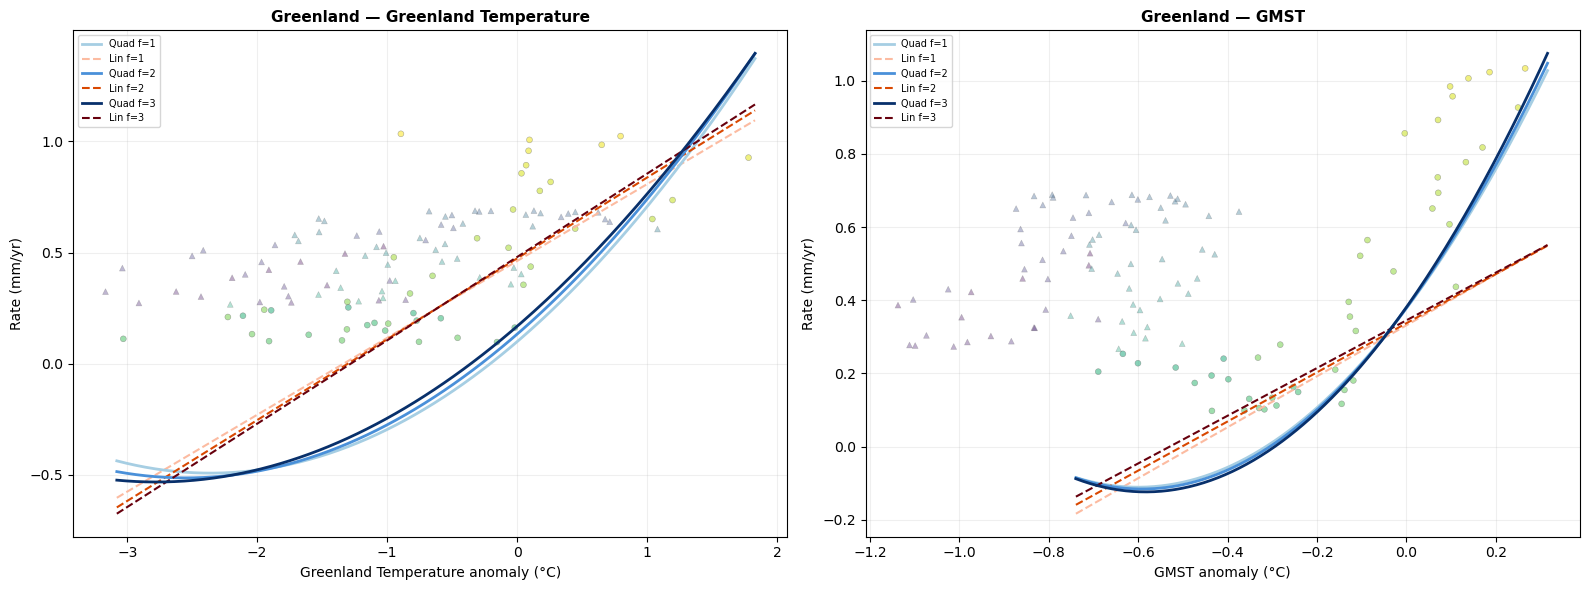

In [20]:
# Map Greenland T onto fred_year grid for scatter
df_gr_temp_rebased = read_berkeley_earth(f'{RAW_DIR}/gmst/berkEarth_greenland_surfaceT.txt')
gr_annual = df_gr_temp_rebased.groupby(df_gr_temp_rebased.index.year).agg(
    T_gr=('temperature', 'mean'), n=('temperature', 'count'))
gr_annual = gr_annual[gr_annual['n'] >= 10]
gr_annual_years = gr_annual.index.values
T_gr_rebased = gr_annual['T_gr'].values
bl_mask_annual = (gr_annual_years >= 1995) & (gr_annual_years <= 2005)
T_gr_rebased -= T_gr_rebased[bl_mask_annual].mean()

mask_gr_fred = np.isin(gr_annual_years, fred_year)
mask_fred_gr = np.isin(fred_year, gr_annual_years)
T_gr_on_fred = np.full_like(fred_year, np.nan, dtype=float)
T_gr_on_fred[mask_fred_gr] = T_gr_rebased[mask_gr_fred]

rates_greenland = rates.get('Greenland', np.full_like(fred_year, np.nan))

plot_greenland_local_vs_gmst(
    gr_local_taper_results, gr_gmst_taper_results,
    rates_greenland, fred_year, T_gr_on_fred, T_annual_vals,
    yrs_gr_local, F_MAX_VALUES,
    save_path=f'{FIG_DIR}/component_greenland_local_vs_gmst.png',
)

## 4. Endpoint Rate Discrepancy

Compare observed (kernel-smoothed) rate at the end of each record with
the model-implied rate to diagnose any systematic endpoint bias.

In [21]:
# ── Endpoint rate discrepancy ──
print('ENDPOINT RATE DISCREPANCY')
print('=' * 95)
print(f'{"Component":15s} {"End yr":>6s} {"T (°C)":>8s} {"Obs rate":>12s} '
      f'{"Model rate":>14s} {"Discrepancy":>14s}')
print('-' * 95)

for name in ['Total GMSL', 'Thermosteric', 'Glaciers', 'Greenland']:
    if name not in rates or name not in model_rates:
        continue
    r = rates[name]
    T_r = T_for_rate[name]
    valid = np.isfinite(r)
    if not np.any(valid):
        continue

    last_idx = np.where(valid)[0][-1]
    rate_obs = r[last_idx]
    T_end = T_r[last_idx]
    yr_end = fred_year[last_idx]

    mr = model_rates[name]
    rate_model = (np.median(mr['a']) * T_end**2 + np.median(mr['b']) * T_end
                  + np.median(mr['c'])) * M_TO_MM
    disc = rate_obs - rate_model

    print(f'{name:15s} {yr_end:6.0f} {T_end:8.3f} {rate_obs:12.3f} '
          f'{rate_model:14.3f} {disc:+14.3f}')

print('=' * 95)
print('Positive discrepancy: observed rate exceeds model expectation')

ENDPOINT RATE DISCREPANCY
Component       End yr   T (°C)     Obs rate     Model rate    Discrepancy
-----------------------------------------------------------------------------------------------
Total GMSL        2018    0.323        5.102          4.511         +0.591
Thermosteric      2018    0.323        1.366          1.466         -0.099
Glaciers          2018    0.323        0.697          0.773         -0.076
Greenland         2018    0.323        1.016          1.017         -0.001
Positive discrepancy: observed rate exceeds model expectation
